#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import ensemble

In [3]:
#Import elastic net

import joblib

model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/ElasticNet.pkl')

In [4]:
ensemble_features = model_1.feature_names_in_
ensemble_features

array(['ENSG00000198712', 'ENSG00000198804', 'ENSG00000198938', ...,
       'ENSG00000197838', 'ENSG00000167751', 'ENSG00000182415'],
      dtype=object)

In [5]:
import pickle

with open('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_features.pkl', 'rb') as f:
    ensemble_y_train_features_loaded = pickle.load(f)

print(ensemble_y_train_features_loaded)

Index(['1,5-anhydroglucitol (1,5-AG)', '1-arachidonoyl-GPC (20:4n6)',
       '1-arachidonoyl-GPE (20:4n6)', '1-arachidonoyl-GPI (20:4)',
       '1-linoleoylglycerol (18:2)', '1-linoleoyl-GPC (18:2)',
       '1-oleoylglycerol (1-monoolein)', '1-oleoyl-GPE (18:1)',
       '1-palmitoleoyl-GPC (16:1)', '1-palmitoylglycerol (1-monopalmitin)',
       ...
       'urea', 'uridine', 'valine', 'valylglycine', 'xanthine', 'xanthosine',
       '3-phosphoglycerate', 'dehydroascorbate', 'pyruvate',
       'phosphoenolpyruvate (PEP)'],
      dtype='object', length=218)


In [6]:
#Import random forest regressor

model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Random Forest Regressor.pkl')

In [7]:
#Import final estimator

final_estimator = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/Ensemble.pkl')

#Data processing for ensemble prediction

In [18]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Pan_TPM.csv', index_col = 0)
rna.index.name = None
rna = rna.T
rna.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-D8-A146-01A-31R-A115-07,49.6341,9.3826,115.1737,20.1202,6.1859,10.9585,30.9154,47.9991,19.9032,56.4289,...,0.0,0.0,0.4513,0.0,0.0,0.0,10.5835,0.0,0.0411,1.1776
TCGA-AQ-A0Y5-01A-11R-A14M-07,12.0296,0.3785,134.9047,15.5758,4.3777,4.0015,29.7787,91.9948,15.5230,51.4084,...,0.0,0.0,0.1525,0.0,0.0,0.0,26.3496,0.0,0.0387,1.3672
TCGA-C8-A274-01A-11R-A16F-07,90.4249,0.0000,110.8229,31.8373,15.4869,3.3594,6.9632,33.7734,9.6288,61.4116,...,0.0,0.0,0.3309,0.0,0.0,0.0,25.0229,0.0,0.0669,0.5202


In [19]:
rna = rna.reindex(ensemble_features, axis = 'columns')
rna.head(3)

,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D8-A146-01A-31R-A115-07,24344.3785,16191.8522,19880.8536,13343.2173,17287.6749,5208.1979,12236.5064,12141.7301,1774.5191,11131.6684,...,0.0,0.0402,0.0162,0.1149,0.1394,0.0562,0.0,0.0749,0.0831,0.0
TCGA-AQ-A0Y5-01A-11R-A14M-07,15466.3528,22624.9765,22247.2836,12629.4103,18353.2198,7174.4777,9078.7267,7283.1951,2156.9917,8003.6833,...,0.0,0.0000,0.0152,0.0902,0.0000,0.0000,0.0,0.0000,0.1173,0.0
TCGA-C8-A274-01A-11R-A16F-07,21705.3843,38997.7958,44549.4302,19402.3325,26656.2610,10667.9069,12433.0264,8790.3434,1560.1601,16863.2656,...,0.0,0.0000,0.0056,0.0000,0.0000,0.0131,0.0,0.6273,0.0290,0.0


In [22]:
def filter_model_features(df):
  na_features = []
  filtered_data = pd.DataFrame(index=df.index, columns=ensemble_features)
  for feature in ensemble_features:
    if feature in df.columns:
      filtered_data[feature] = df[feature]
    else:
      filtered_data[feature] = np.nan
      na_features.append(feature)

  print(f'Features not in data and placed as NaN: {len(na_features)}')

  return filtered_data

In [23]:
data_ensemble_processed = rna.apply(lambda x: np.log2(x + 1))
data_ensemble_processed = filter_model_features(data_ensemble_processed)
data_ensemble_processed.head(3)

Features not in data and placed as NaN: 0


,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,ENSG00000198888,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D8-A146-01A-31R-A115-07,14.571360,13.983070,14.279165,13.703927,14.077540,12.346846,13.579022,13.567805,10.794025,13.442512,...,0.0,0.056861,0.023184,0.156914,0.188274,0.078883,0.0,0.104202,0.115166,0.0
TCGA-AQ-A0Y5-01A-11R-A14M-07,13.916939,14.465692,14.441406,13.624614,14.163824,12.808859,13.148433,12.830554,11.075474,12.966629,...,0.0,0.000000,0.021764,0.124593,0.000000,0.000000,0.0,0.000000,0.160017,0.0
TCGA-C8-A274-01A-11R-A16F-07,14.405832,15.251142,15.443152,14.244017,14.702241,13.381125,13.602006,13.101868,10.608403,14.041682,...,0.0,0.000000,0.008057,0.000000,0.000000,0.018777,0.0,0.702480,0.041243,0.0


#Ensemble predictions

In [24]:
#Ensemble predictions

def predict_metabolites_ensemble(model_1, model_2, final_estimator, filtered_data):
  pred_1 = model_1.predict(filtered_data)
  pred_2 = model_2.predict(filtered_data)
  stacked_preds = np.hstack([pred_1, pred_2])
  pred_metabolites = final_estimator.predict(stacked_preds)
  pred_metabolites = pd.DataFrame(pred_metabolites, index = filtered_data.index, columns = ensemble_y_train_features_loaded)

  return pred_metabolites

In [25]:
metabolites = predict_metabolites_ensemble(model_1, model_2, final_estimator, data_ensemble_processed)
metabolites.head(3)

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-D8-A146-01A-31R-A115-07,20.451277,17.796924,20.485102,19.070045,19.915419,20.499123,20.491576,20.971786,18.009164,21.728516,...,22.475490,22.835995,26.283377,17.244895,23.449248,17.800018,20.986253,18.275416,19.310743,18.767213
TCGA-AQ-A0Y5-01A-11R-A14M-07,20.228975,18.274936,22.799245,20.009314,19.803477,20.594868,20.526713,21.782385,18.571024,22.517361,...,22.049972,22.388054,26.655827,17.553837,24.062744,17.102742,21.293311,18.154438,19.995300,19.034779
TCGA-C8-A274-01A-11R-A16F-07,20.332724,18.551455,21.472264,19.683919,19.495994,20.756305,20.771998,21.192428,18.092383,22.056481,...,21.924352,22.737355,25.944872,16.912491,23.194835,17.648461,21.253346,18.364341,19.524885,19.172754


#Data analysis and visualisation

In [26]:
metabolites.head(3)

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-D8-A146-01A-31R-A115-07,20.451277,17.796924,20.485102,19.070045,19.915419,20.499123,20.491576,20.971786,18.009164,21.728516,...,22.475490,22.835995,26.283377,17.244895,23.449248,17.800018,20.986253,18.275416,19.310743,18.767213
TCGA-AQ-A0Y5-01A-11R-A14M-07,20.228975,18.274936,22.799245,20.009314,19.803477,20.594868,20.526713,21.782385,18.571024,22.517361,...,22.049972,22.388054,26.655827,17.553837,24.062744,17.102742,21.293311,18.154438,19.995300,19.034779
TCGA-C8-A274-01A-11R-A16F-07,20.332724,18.551455,21.472264,19.683919,19.495994,20.756305,20.771998,21.192428,18.092383,22.056481,...,21.924352,22.737355,25.944872,16.912491,23.194835,17.648461,21.253346,18.364341,19.524885,19.172754


In [27]:
annot = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Samples_Tissue_Type.csv', index_col = 0)
annot.index.name = None
annot.head(3)

,patient_barcorde,sample_type,samples_tissue_type
TCGA-02-0047-01A-01R-1849-01,TCGA-02-0047,Tumour,TCGA-GBM
TCGA-02-0055-01A-01R-1849-01,TCGA-02-0055,Tumour,TCGA-GBM
TCGA-02-2483-01A-01R-1849-01,TCGA-02-2483,Tumour,TCGA-GBM


In [28]:
print(rna.shape)
print(metabolites.shape)

(10668, 2884)
(10668, 218)


In [29]:
met_annot = pd.concat([annot[['sample_type', 'samples_tissue_type']], metabolites], axis = 'columns')
met_annot.head(3)

,sample_type,samples_tissue_type,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,21.022684,18.496179,20.572713,19.500851,18.798773,20.432639,20.101213,20.878373,...,22.619838,22.817244,25.163689,18.373848,23.231496,17.391563,20.453104,19.296099,19.704158,18.160732
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,21.037139,18.277534,20.916118,19.683940,19.148122,20.166717,20.240770,20.677028,...,22.795777,22.889259,25.674353,17.963526,23.617926,17.974664,21.219995,19.727817,19.273830,18.802600
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,20.456643,18.342361,21.680373,19.803436,19.251052,20.275109,20.525656,20.618897,...,22.125119,21.923290,25.553406,16.487326,22.925822,17.555359,20.612982,18.530802,19.698874,18.333662


In [30]:
def get_log2FC(df, tumour_type):
  data = df.copy()
  data = data[data['samples_tissue_type'] == tumour_type]
  data_numeric = data.drop(columns=['samples_tissue_type'])
  res = pd.DataFrame(data_numeric.groupby(['sample_type']).median())
  res = res.T
  if 'Normal'in res.columns:
    res['log2FC'] = np.log2(res['Tumour'] / res['Normal'])
    res = res.drop(columns = {'Normal', 'Tumour'})
    res = res.rename(columns = {'log2FC' : tumour_type})
    res.index.name = None
    res.columns.name = None
    return res
  else:
    pass


In [31]:
tumour_types = met_annot.samples_tissue_type.value_counts().index.to_list()

df_plot = pd.DataFrame()

for i in tumour_types:
  df_plot = pd.concat([df_plot, get_log2FC(met_annot, i)], axis = 'columns')

df_plot

,TCGA-BRCA,TCGA-KIRC,TCGA-LUAD,TCGA-UCEC,TCGA-THCA,TCGA-HNSC,TCGA-LUSC,TCGA-PRAD,TCGA-COAD,TCGA-STAD,...,TCGA-SARC,TCGA-ESCA,TCGA-PCPG,TCGA-PAAD,TCGA-READ,TCGA-GBM,TCGA-THYM,TCGA-SKCM,TCGA-KICH,TCGA-CHOL
"1,5-anhydroglucitol (1,5-AG)",-0.016728,0.032823,-0.025106,-0.037677,0.010471,-0.009233,-0.044089,-0.010009,-0.050113,-0.021338,...,-0.017230,-0.013328,-0.003882,0.002638,-0.058690,-0.045964,0.003005,0.013116,-0.009084,-0.054549
1-arachidonoyl-GPC (20:4n6),0.021889,-0.011697,0.008542,0.042253,0.006104,-0.008505,0.030555,0.032594,-0.007784,-0.029014,...,0.002651,-0.015110,-0.062394,-0.006964,-0.006129,0.035276,-0.011697,0.056456,0.076579,-0.115078
1-arachidonoyl-GPE (20:4n6),0.060038,-0.080809,-0.011040,0.049295,-0.011995,0.006669,-0.006439,0.013952,0.024277,-0.016069,...,-0.003387,-0.005785,-0.002878,0.035584,0.036235,0.103937,0.028040,0.050680,0.011867,-0.160284
1-arachidonoyl-GPI (20:4),0.068003,-0.073313,0.018395,0.095776,0.001603,0.028447,0.042522,0.033855,0.023743,-0.009234,...,0.008615,-0.016210,-0.017307,0.015440,0.036709,0.023942,0.027581,0.047166,0.009723,-0.112141
1-linoleoylglycerol (18:2),0.025182,-0.061857,-0.010240,0.095286,-0.094562,-0.003421,0.015630,-0.014983,-0.025416,-0.053277,...,0.033757,-0.004346,-0.033702,0.051016,0.001790,0.051054,-0.014247,0.086892,0.027076,-0.241914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
xanthosine,0.008791,-0.184353,0.042996,0.042022,0.019178,0.006478,0.027286,-0.000319,0.021333,-0.024412,...,-0.032023,-0.061686,0.080591,0.044621,0.047403,-0.036144,-0.004831,-0.046619,-0.055662,-0.091432
3-phosphoglycerate,0.022425,-0.072837,0.025701,-0.011256,-0.014806,0.041242,0.011254,-0.013494,0.030920,0.042766,...,-0.037305,0.035052,-0.071765,0.019388,0.030361,0.044367,0.034600,-0.021129,0.024275,-0.070983
dehydroascorbate,-0.017198,-0.049714,0.025004,-0.051007,-0.030487,-0.030684,0.040169,0.018917,-0.045203,0.019640,...,0.040357,-0.020417,0.046127,0.027022,-0.030631,-0.046527,0.084846,-0.084288,0.017582,0.090847
pyruvate,0.042254,0.016390,0.003844,0.046111,-0.017417,-0.004237,-0.003805,0.020165,-0.046205,0.018811,...,0.004218,0.022728,0.008921,0.013408,-0.046164,0.081077,0.008338,0.031550,0.000465,-0.003045


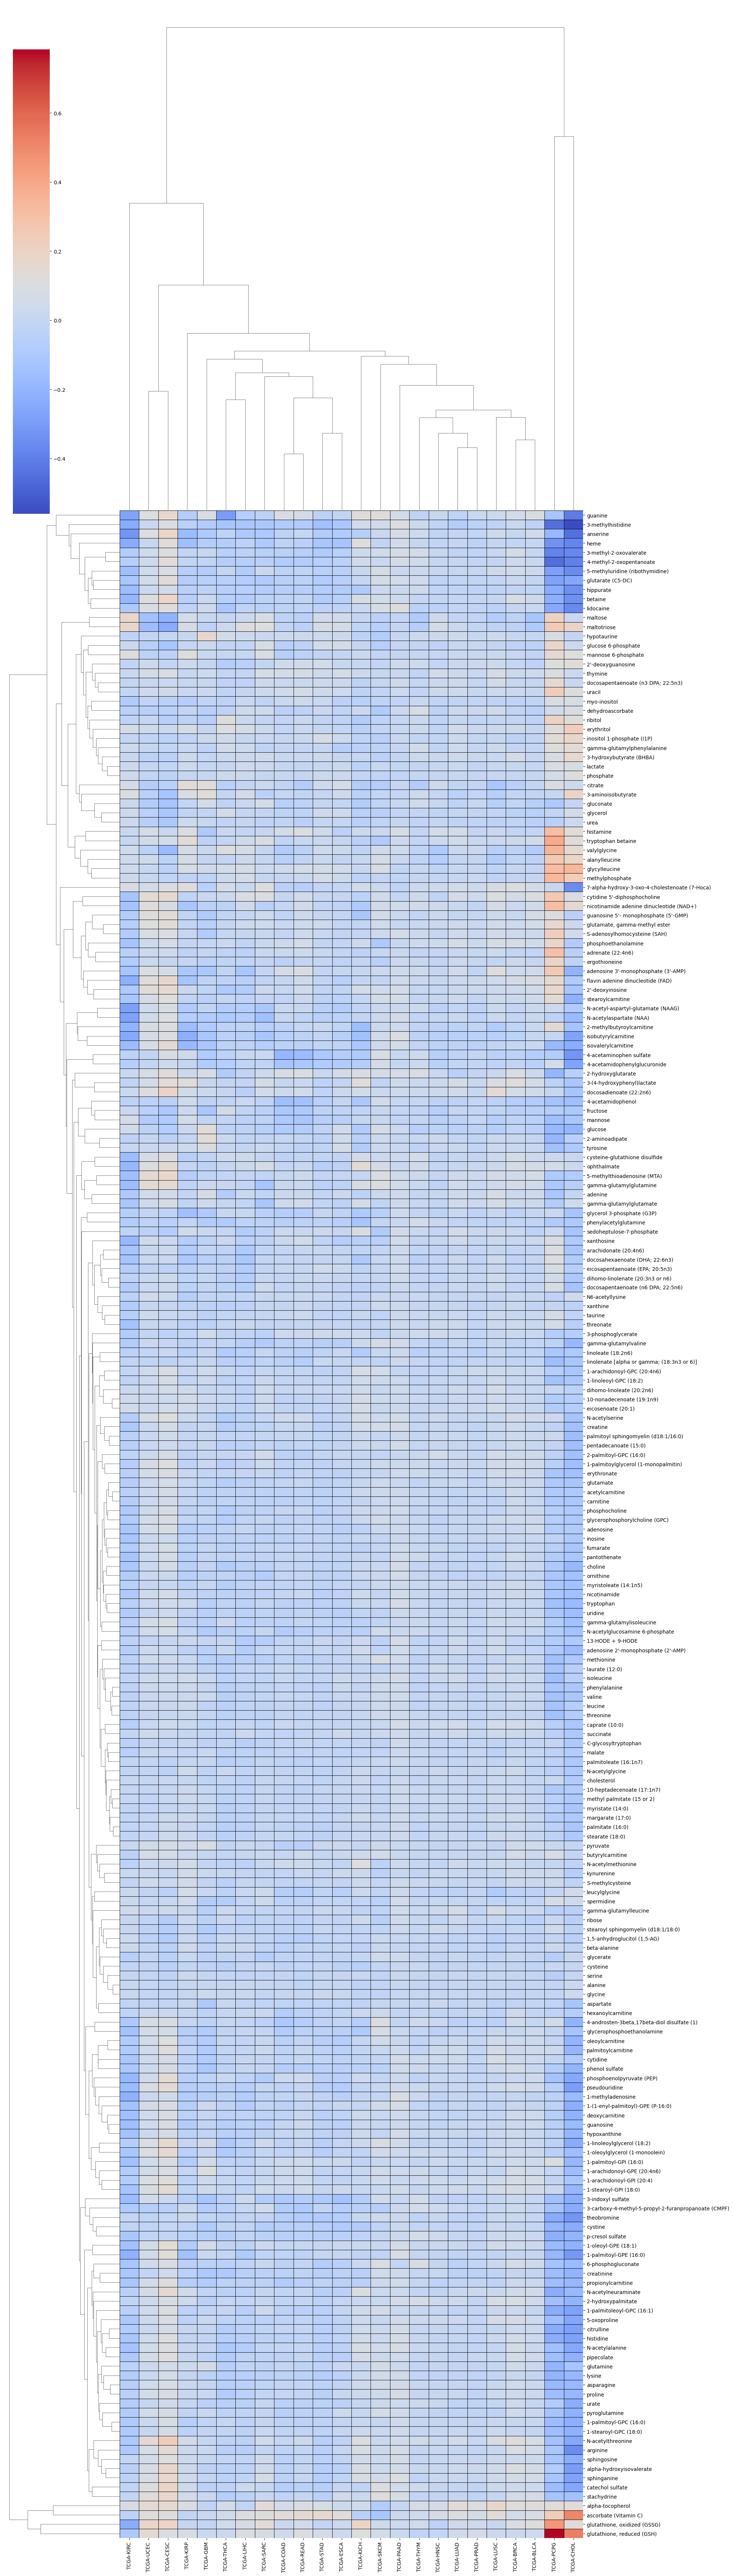

In [32]:
sns.clustermap(df_plot.fillna(0), figsize=(20,70), cmap = sns.color_palette("coolwarm", as_cmap=True), linewidths = 0.5, linecolor = 'black')
# plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolite_clustermap.svg')
plt.show()

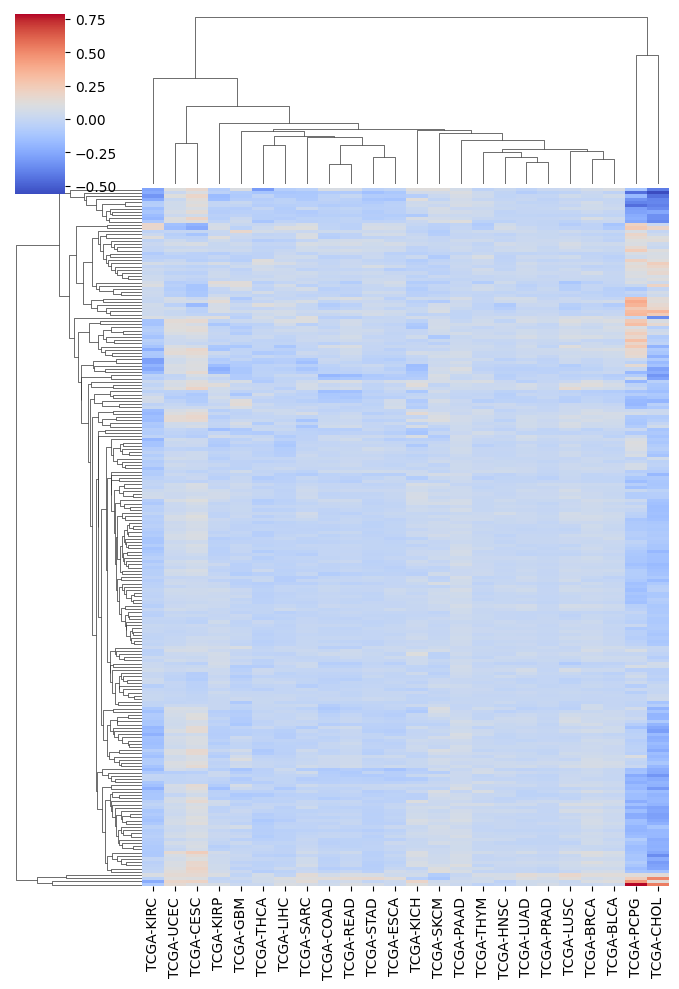

In [33]:
g = sns.clustermap(df_plot.fillna(0), cmap = sns.color_palette("coolwarm", as_cmap=True))
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_ylabel('')
# plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolite_clustermap_wo_metabolite_names.svg')
plt.show()

#BRCA analysis

In [34]:
brca_annotations = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/TCGA/TCGA_DESeq2/TCGA_BRCA_annotation_withCNV.txt', sep = '\t')
brca_annotations

,Transcriptomic_Sample,Tumour,HR_status,HER2_status,TNBC_status,PI3K_mutation_status,PTEN_status,PI3K_activity_status,MYC_status,Disease_Stage,PAM50_Classification
0,TCGA-3C-AAAU-01A-11R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_Deletion,PI3K_PTEN_mut,MYC_WT,NaN,LumA
1,TCGA-3C-AALI-01A-11R-A41B-07,Tumour,HR+,HER2+,TNBC-,PI3K_WT,PTEN_Deletion,PI3K_PTEN_mut,MYC_Gain,Stage_II,Her2
2,TCGA-3C-AALJ-01A-31R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_Amplification,Stage_II,LumB
3,TCGA-3C-AALK-01A-11R-A41B-07,Tumour,HR+,HER2+,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_I,LumA
4,TCGA-4H-AAAK-01A-12R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_Gain,Stage_III,LumA
...,...,...,...,...,...,...,...,...,...,...,...
1219,TCGA-WT-AB44-01A-11R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_I,LumA
1220,TCGA-XX-A899-01A-11R-A36F-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_WT,Stage_III,LumA
1221,TCGA-XX-A89A-01A-11R-A36F-07,Tumour,HR+,HER2-,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_II,LumA
1222,TCGA-Z7-A8R5-01A-42R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_WT,Stage_III,LumA


In [35]:
tumour_samples = brca_annotations[(brca_annotations['Tumour'] != 'Normal')]['Transcriptomic_Sample']
tumour_samples = list(tumour_samples)
len(tumour_samples)

1111

In [36]:
pi3k_status = brca_annotations[brca_annotations['Transcriptomic_Sample'].isin(tumour_samples)][['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k_status = pi3k_status.replace('PI3K_PTEN_mut', 'PI3K_PTEN_MUT')
pi3k_status = pi3k_status.set_index('Transcriptomic_Sample')
pi3k_status.index.name = None
pi3k_status

,PI3K_activity_status
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALJ-01A-31R-A41B-07,PI3K_PTEN_WT
TCGA-3C-AALK-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-4H-AAAK-01A-12R-A41B-07,PI3K_PTEN_WT
...,...
TCGA-WT-AB44-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-XX-A899-01A-11R-A36F-07,PI3K_PTEN_WT
TCGA-XX-A89A-01A-11R-A36F-07,PI3K_PTEN_MUT
TCGA-Z7-A8R5-01A-42R-A41B-07,PI3K_PTEN_WT


In [37]:
met_annot.head(3)

,sample_type,samples_tissue_type,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,21.022684,18.496179,20.572713,19.500851,18.798773,20.432639,20.101213,20.878373,...,22.619838,22.817244,25.163689,18.373848,23.231496,17.391563,20.453104,19.296099,19.704158,18.160732
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,21.037139,18.277534,20.916118,19.683940,19.148122,20.166717,20.240770,20.677028,...,22.795777,22.889259,25.674353,17.963526,23.617926,17.974664,21.219995,19.727817,19.273830,18.802600
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,20.456643,18.342361,21.680373,19.803436,19.251052,20.275109,20.525656,20.618897,...,22.125119,21.923290,25.553406,16.487326,22.925822,17.555359,20.612982,18.530802,19.698874,18.333662


In [38]:
metabolites_brca = met_annot[met_annot.index.isin(tumour_samples)]
metabolites_brca.head(2)

,sample_type,samples_tissue_type,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-3C-AAAU-01A-11R-A41B-07,Tumour,TCGA-BRCA,19.472670,18.711865,23.084855,20.695495,20.380722,20.892547,21.809686,21.729793,...,21.504338,22.001147,26.081018,17.764548,23.720675,17.948757,20.199241,18.530318,20.256269,18.663075
TCGA-3C-AALI-01A-11R-A41B-07,Tumour,TCGA-BRCA,20.011485,18.087098,21.182585,19.893911,19.973018,20.542091,20.745405,21.734747,...,22.381308,23.510936,26.302401,15.999285,23.204169,18.454894,21.090912,18.066712,19.030239,19.471298


In [39]:
metabolites_brca = pd.concat([pi3k_status, metabolites_brca], axis = 'columns')
metabolites_brca = metabolites_brca.drop(columns = ['sample_type', 'samples_tissue_type'])
metabolites_brca.head(2)

,PI3K_activity_status,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT,19.472670,18.711865,23.084855,20.695495,20.380722,20.892547,21.809686,21.729793,18.680258,...,21.504338,22.001147,26.081018,17.764548,23.720675,17.948757,20.199241,18.530318,20.256269,18.663075
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT,20.011485,18.087098,21.182585,19.893911,19.973018,20.542091,20.745405,21.734747,17.996835,...,22.381308,23.510936,26.302401,15.999285,23.204169,18.454894,21.090912,18.066712,19.030239,19.471298


In [40]:
metabolites_brca_grouped = metabolites_brca.groupby(['PI3K_activity_status']).median()
metabolites_brca_grouped = metabolites_brca_grouped.T
metabolites_brca_grouped['log2FC'] = np.log2(metabolites_brca_grouped['PI3K_PTEN_MUT'] / metabolites_brca_grouped['PI3K_PTEN_WT'])
metabolites_brca_grouped = metabolites_brca_grouped.drop(columns = ['PI3K_PTEN_WT', 'PI3K_PTEN_MUT'])
metabolites_brca_grouped.index.name = None
metabolites_brca_grouped = metabolites_brca_grouped.sort_values(by = 'log2FC', ascending = False)
metabolites_brca_grouped

PI3K_activity_status,log2FC
alpha-tocopherol,0.010892
3-aminoisobutyrate,0.009915
3-phosphoglycerate,0.005654
cytidine,0.005550
2'-deoxyguanosine,0.005393
...,...
glucose,-0.005283
heme,-0.006139
5-methyluridine (ribothymidine),-0.006939
2-hydroxyglutarate,-0.009880


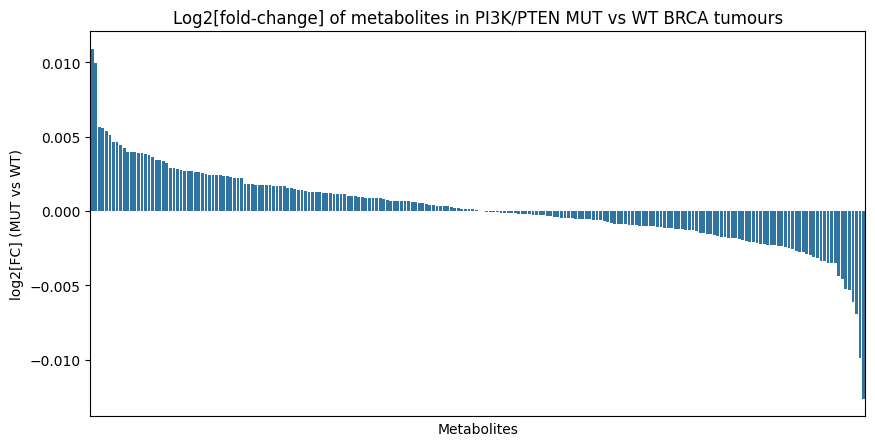

In [41]:
plt.figure(figsize = (10, 5))
sns.barplot(data = metabolites_brca_grouped, x = metabolites_brca_grouped.index, y = 'log2FC')
plt.xticks([])
plt.xlabel('Metabolites')
plt.ylabel('log2[FC] (MUT vs WT)')
plt.title('Log2[fold-change] of metabolites in PI3K/PTEN MUT vs WT BRCA tumours')
# plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_metabolites_log2FC.svg')
plt.show()

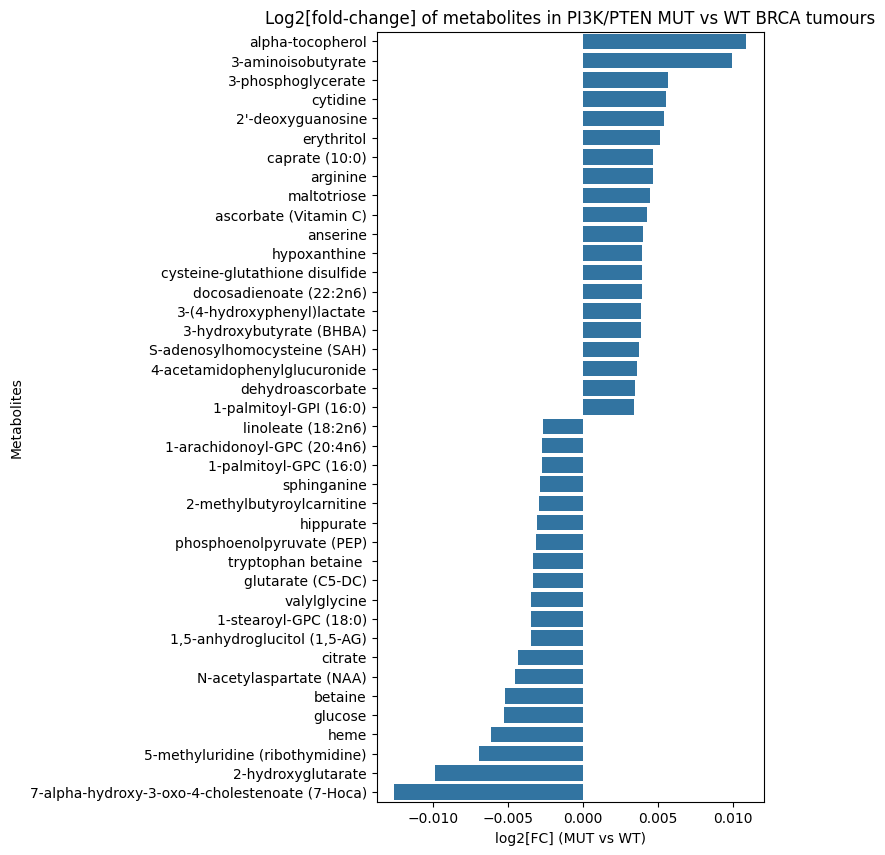

In [42]:
metabolites_brca_grouped_top = pd.concat([metabolites_brca_grouped.head(20), metabolites_brca_grouped.tail(20)], axis = 'index')
plt.figure(figsize = (5, 10))
sns.barplot(data = metabolites_brca_grouped_top, x ='log2FC', y =  metabolites_brca_grouped_top.index)
plt.ylabel('Metabolites')
plt.xlabel('log2[FC] (MUT vs WT)')
plt.title('Log2[fold-change] of metabolites in PI3K/PTEN MUT vs WT BRCA tumours')
# plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_top_metabolites_log2FC.svg')
plt.show()